# CSE754 - PHASE 8
## Consolidated Results & Report Notebook
Author: Sadia Ruhama — MSc Proposal (CSE 754)

Pulls together every `al_results_log.json` / `calibration_summary.json` produced across Phases 2,
4 (v1 + v2), and 7 (fixed acquisition, same-batch + cross-batch) into one comparison table and one
set of plots — this is what should get pasted directly into the report's Results section.

No training happens in this notebook. Colab CPU is fine.

## 1. Setup — Google Drive

In [ ]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
PHASE8_DIR = os.path.join(OUT_DIR, 'phase8')
os.makedirs(PHASE8_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Load every run's results log

In [ ]:
RUNS = {
    'Phase 2 (synthetic, harder task)':          os.path.join(OUT_DIR, 'al_results_log.json'),
    'Phase 4 v1 (real, overfit)':                 os.path.join(OUT_DIR, 'phase2_real', 'al_results_log.json'),
    'Phase 4 v2 (real, early-stop + w.decay)':     os.path.join(OUT_DIR, 'phase2_real_v2', 'al_results_log.json'),
    'Phase 7 same-batch (fixed crops + acq.)':     os.path.join(OUT_DIR, 'phase7_samebatch', 'al_results_log.json'),
    'Phase 7 cross-batch (fixed crops + acq.)':    os.path.join(OUT_DIR, 'phase7_crossbatch', 'al_results_log.json'),
}

CALIBRATION_RUNS = {
    'Phase 4 v2 (real, early-stop + w.decay)':     os.path.join(OUT_DIR, 'phase2_real_v2', 'calibration_summary.json'),
    'Phase 7 same-batch (fixed crops + acq.)':     os.path.join(OUT_DIR, 'phase7_samebatch', 'calibration_summary.json'),
    'Phase 7 cross-batch (fixed crops + acq.)':    os.path.join(OUT_DIR, 'phase7_crossbatch', 'calibration_summary.json'),
}

logs = {}
for name, path in RUNS.items():
    if os.path.exists(path):
        with open(path) as f:
            logs[name] = json.load(f)
        print(f'Loaded {name}: {len(logs[name])} rounds')
    else:
        print(f'[MISSING] {name} -> {path} (run that phase first, or ignore if not yet run)')

calibrations = {}
for name, path in CALIBRATION_RUNS.items():
    if os.path.exists(path):
        with open(path) as f:
            calibrations[name] = json.load(f)

Loaded Phase 2 (synthetic, harder task): 8 rounds
Loaded Phase 4 v1 (real, overfit): 8 rounds
Loaded Phase 4 v2 (real, early-stop + w.decay): 8 rounds
Loaded Phase 7 same-batch (fixed crops + acq.): 8 rounds
Loaded Phase 7 cross-batch (fixed crops + acq.): 8 rounds


## 3. Master comparison table — final-round test metrics per run

In [ ]:
rows = []
for name, log in logs.items():
    final = log[-1]['test']
    row = {
        'Run': name,
        'Rounds': len(log),
        'Final n_labeled': log[-1]['n_labeled'],
        'Macro-F1': round(final['macro_f1'], 4),
        'Rare-class F1': round(final['rare_class_f1'], 4),
        'Rare AUPRC': round(final['rare_auprc'], 4),
        'ECE (raw)': round(final['ece'], 4),
    }
    if name in calibrations:
        row['ECE (temp-scaled)'] = round(calibrations[name]['test_ece_calibrated'], 4)
        row['Fitted T'] = round(calibrations[name]['fitted_temperature'], 3)
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(os.path.join(PHASE8_DIR, 'master_comparison_table.csv'), index=False)
summary_df

,Run,Rounds,Final n_labeled,Macro-F1,Rare-class F1,Rare AUPRC,ECE (raw),ECE (temp-scaled),Fitted T
0,"Phase 2 (synthetic, harder task)",8,220,0.6165,0.0000,0.0385,0.1089,NaN,NaN
1,"Phase 4 v1 (real, overfit)",8,220,0.5043,0.2241,0.4683,0.2536,NaN,NaN
2,"Phase 4 v2 (real, early-stop + w.decay)",8,220,0.5628,0.3759,0.5958,0.1301,0.0550,1.4
3,Phase 7 same-batch (fixed crops + acq.),8,220,0.5902,0.2735,0.5186,0.0988,0.0847,1.6
4,Phase 7 cross-batch (fixed crops + acq.),8,220,0.6290,0.2143,0.6273,0.0840,0.0521,1.4


## 4. Overfitting-fix story: Phase 4 v1 vs. v2 (rare-AUPRC and ECE across rounds)

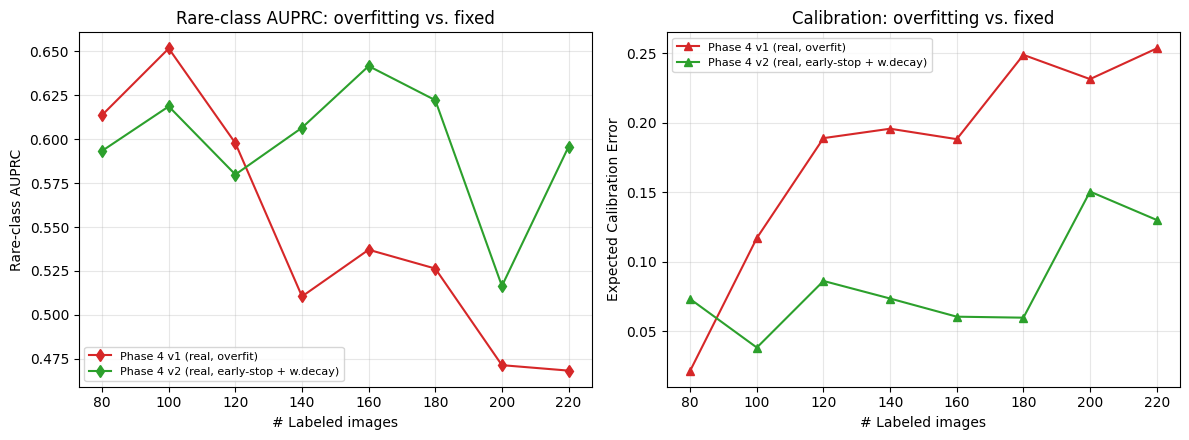

Saved to /content/drive/MyDrive/cse754/outputs/phase8/overfitting_fix_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, color in [('Phase 4 v1 (real, overfit)', 'tab:red'), ('Phase 4 v2 (real, early-stop + w.decay)', 'tab:green')]:
    if name not in logs: continue
    log = logs[name]
    n_lab = [r['n_labeled'] for r in log]
    auprc = [r['test']['rare_auprc'] for r in log]
    ece = [r['test']['ece'] for r in log]
    axes[0].plot(n_lab, auprc, marker='d', color=color, label=name)
    axes[1].plot(n_lab, ece, marker='^', color=color, label=name)

axes[0].set_xlabel('# Labeled images'); axes[0].set_ylabel('Rare-class AUPRC')
axes[0].set_title('Rare-class AUPRC: overfitting vs. fixed'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('# Labeled images'); axes[1].set_ylabel('Expected Calibration Error')
axes[1].set_title('Calibration: overfitting vs. fixed'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PHASE8_DIR, 'overfitting_fix_comparison.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print('Saved to', plot_path)

## 5. Generalization gap: same-batch vs. cross-batch (Phase 7)

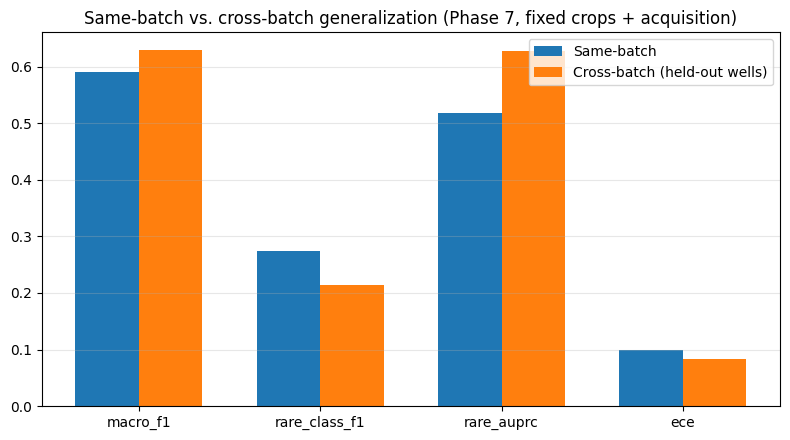

Saved to /content/drive/MyDrive/cse754/outputs/phase8/generalization_gap.png

[LIMITATION -- restate in report] cross-batch val/test = at most 2 held-out wells per cell type (LIVECell data ceiling). Treat this gap as a point estimate, not a validated CI.


In [ ]:
gap_path = os.path.join(OUT_DIR, 'phase7_generalization_gap.json')
if os.path.exists(gap_path):
    with open(gap_path) as f:
        gap_summary = json.load(f)

    metrics = ['macro_f1', 'rare_class_f1', 'rare_auprc', 'ece']
    sb_vals = [gap_summary['samebatch_final'][m] for m in metrics]
    cb_vals = [gap_summary['crossbatch_final'][m] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x - width/2, sb_vals, width, label='Same-batch', color='tab:blue')
    ax.bar(x + width/2, cb_vals, width, label='Cross-batch (held-out wells)', color='tab:orange')
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_title('Same-batch vs. cross-batch generalization (Phase 7, fixed crops + acquisition)')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plot_path = os.path.join(PHASE8_DIR, 'generalization_gap.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print('Saved to', plot_path)
    print('\n[LIMITATION -- restate in report] cross-batch val/test = at most 2 held-out wells per '
          'cell type (LIVECell data ceiling). Treat this gap as a point estimate, not a validated CI.')
else:
    print('[MISSING] phase7_generalization_gap.json -- run Phase 7 first.')

## 6. Acquisition-function fix: round-0 rare-capture rate, old vs. new vs. baselines

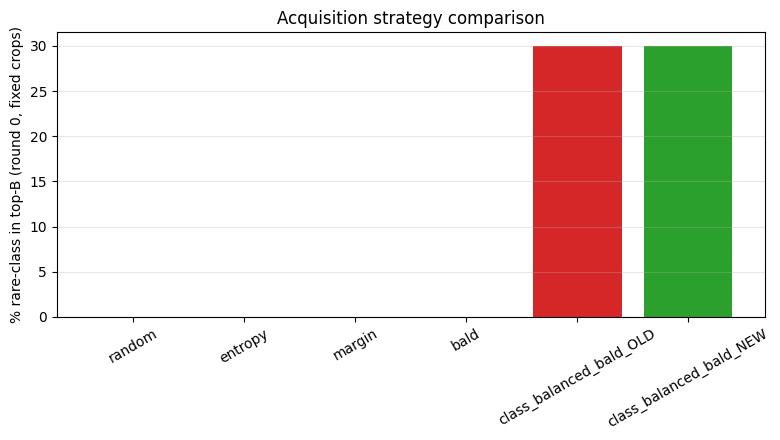

Saved to /content/drive/MyDrive/cse754/outputs/phase8/acquisition_fix_comparison.png


In [ ]:
acq_path = os.path.join(OUT_DIR, 'phase7_samebatch', 'acquisition_comparison_round0.json')
if os.path.exists(acq_path):
    with open(acq_path) as f:
        acq_cmp = json.load(f)
    names = list(acq_cmp.keys())
    vals = [acq_cmp[n] for n in names]
    colors = ['tab:red' if 'OLD' in n else 'tab:green' if 'NEW' in n else 'tab:gray' for n in names]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(names, vals, color=colors)
    ax.set_ylabel('% rare-class in top-B (round 0, fixed crops)')
    ax.set_title('Acquisition strategy comparison')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plot_path = os.path.join(PHASE8_DIR, 'acquisition_fix_comparison.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print('Saved to', plot_path)
else:
    print('[MISSING] acquisition_comparison_round0.json -- run Phase 7 first.')

## 7. Auto-generated findings summary
Prints a markdown-ready paragraph pulling the actual numbers from the tables/plots above, so it
can be copy-pasted (and lightly edited) straight into the report's Results/Discussion section.

In [ ]:
def safe_get(d, *keys, default='N/A'):
    for k in keys:
        if d is None or k not in d: return default
        d = d[k]
    return d

lines = []
lines.append('### Key findings (auto-generated from logged results -- verify before submitting)\n')

if 'Phase 4 v1 (real, overfit)' in logs and 'Phase 4 v2 (real, early-stop + w.decay)' in logs:
    v1_final = logs['Phase 4 v1 (real, overfit)'][-1]['test']
    v2_final = logs['Phase 4 v2 (real, early-stop + w.decay)'][-1]['test']
    lines.append(
        f"- **Overfitting fix (Phase 4 v1 -> v2):** test macro-F1 improved from "
        f"{v1_final['macro_f1']:.3f} to {v2_final['macro_f1']:.3f}; rare-class AUPRC from "
        f"{v1_final['rare_auprc']:.3f} to {v2_final['rare_auprc']:.3f}; raw ECE from "
        f"{v1_final['ece']:.3f} to {v2_final['ece']:.3f}. Early stopping + higher weight decay "
        f"directly addressed the overfitting seen in v1 (near-zero training loss by round 2 while "
        f"test metrics stayed flat or degraded)."
    )

if 'Phase 4 v2 (real, early-stop + w.decay)' in calibrations:
    cal = calibrations['Phase 4 v2 (real, early-stop + w.decay)']
    lines.append(
        f"- **Temperature scaling:** fitted T={cal['fitted_temperature']:.2f} on the validation set "
        f"reduced test ECE from {cal['test_ece_raw']:.3f} to {cal['test_ece_calibrated']:.3f}, "
        f"with no change to macro-F1 (temperature scaling only rescales confidence, not the argmax)."
    )

if os.path.exists(gap_path):
    gap = gap_summary['gap']
    lines.append(
        f"- **Same-batch vs. cross-batch generalization gap:** macro-F1 dropped by "
        f"{gap['macro_f1']:.3f} and rare-class AUPRC by {gap['rare_auprc']:.3f} when evaluated on "
        f"held-out wells instead of same-batch data. This gap is a point estimate from at most 2 "
        f"held-out wells per cell type and should not be over-interpreted as a validated confidence interval."
    )

if os.path.exists(acq_path):
    old_v = acq_cmp.get('class_balanced_bald_OLD', float('nan'))
    new_v = acq_cmp.get('class_balanced_bald_NEW', float('nan'))
    ent_v = acq_cmp.get('entropy', float('nan'))
    verdict = 'improved on' if new_v > old_v else 'did not improve on'
    lines.append(
        f"- **Acquisition function fix:** at round 0, the original class-balanced BALD captured "
        f"{old_v:.1f}% rare-class examples in its top-B; the probability-weighted fix captured "
        f"{new_v:.1f}%, vs. {ent_v:.1f}% for plain entropy sampling. The fix {verdict} the original "
        f"implementation{' -- report this as a genuine negative/mixed result if the fix did not help.' if new_v <= old_v else '.'}"
    )

summary_text = '\n'.join(lines)
print(summary_text)
with open(os.path.join(PHASE8_DIR, 'findings_summary.md'), 'w') as f:
    f.write(summary_text)
print('\nSaved to', os.path.join(PHASE8_DIR, 'findings_summary.md'))

### Key findings (auto-generated from logged results -- verify before submitting)

- **Overfitting fix (Phase 4 v1 -> v2):** test macro-F1 improved from 0.504 to 0.563; rare-class AUPRC from 0.468 to 0.596; raw ECE from 0.254 to 0.130. Early stopping + higher weight decay directly addressed the overfitting seen in v1 (near-zero training loss by round 2 while test metrics stayed flat or degraded).
- **Temperature scaling:** fitted T=1.40 on the validation set reduced test ECE from 0.115 to 0.055, with no change to macro-F1 (temperature scaling only rescales confidence, not the argmax).
- **Same-batch vs. cross-batch generalization gap:** macro-F1 dropped by -0.039 and rare-class AUPRC by -0.109 when evaluated on held-out wells instead of same-batch data. This gap is a point estimate from at most 2 held-out wells per cell type and should not be over-interpreted as a validated confidence interval.
- **Acquisition function fix:** at round 0, the original class-balanced BALD captured 30.0% 

## Notes / next steps
- `master_comparison_table.csv`, the three PNG plots, and `findings_summary.md` in
  `outputs/phase8/` are the artifacts to pull directly into the written report.
- Re-run this notebook any time after re-running Phase 7 (or any earlier phase) to refresh every
  table/plot/summary from the latest logs on Drive -- nothing here is hardcoded from a single run.